# Multi-Agent Workflows + RAG - LangGraph

Today we'll be looking at an example of a Multi-Agent workflow that's powered by LangGraph, LCEL, and more!

We're going to be, more specifically, looking at a "heirarchical agent teams" from the [AutoGen: Enabling Next-Gen LLM
Applications via Multi-Agent Conversation](https://arxiv.org/pdf/2308.08155) paper.

This will be the final "graph" of our system:

![image](https://i.imgur.com/r5LMMCt.png)

It's important to keep in mind that the actual implementation will be constructed of 3 separate graphs, the final one having 2 graphs as nodes! LangGraph is a heckuva tool!



# 🤝 BREAKOUT ROOM #1

## Dependencies

Since we'll be relying on OpenAI's suite of models to power our agents today, we'll want to provide our OpenAI API Key.

We're also going to be using the Tavily search tool - so we'll want to provide that API key as well!

Instruction for how to obtain the Tavily API key can be found:

1. [Tavily API Key](https://app.tavily.com/sign-in)



In [205]:
import os
from dotenv import load_dotenv

# Load environment variables from .env file
load_dotenv()

print(os.environ["OPENAI_API_KEY"][0:8])

sk-proj-


In [206]:
import nest_asyncio
nest_asyncio.apply()

## Task 1: Simple LangGraph RAG

Now that we have our dependencies set-up - let's create a simple RAG graph that works over our AI Usage Data from previous sessions.

> NOTE: While this particular example is very straight forward - you can "plug in" any complexity of chain you desire as a node in a LangGraph.

### Retrieval

The 'R' in 'RAG' - this is, at this point, fairly straightforward!

#### Data Collection and Processing

A classic first step, at this point, let's grab our desired document!

In [207]:
from langchain_community.document_loaders import DirectoryLoader
from langchain_community.document_loaders import PyMuPDFLoader

directory_loader = DirectoryLoader("data", glob="**/*.pdf", loader_cls=PyMuPDFLoader)

how_people_use_ai_documents = directory_loader.load()

Now we can chunk it down to size!

In [208]:
import tiktoken
from langchain.text_splitter import RecursiveCharacterTextSplitter

def tiktoken_len(text):
    tokens = tiktoken.encoding_for_model("gpt-4o").encode(
        text,
    )
    return len(tokens)

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 750,
    chunk_overlap = 0,
    length_function = tiktoken_len,
)

how_people_use_ai_chunks = text_splitter.split_documents(how_people_use_ai_documents)

Now we've successfully split our single PDF into...

In [209]:
len(how_people_use_ai_chunks)

71

#### Embedding Model and Vector Store

Now that we have our chunked document - lets create a vector store, which will first require us to create an embedding model to get the vector representations of our text!

We'll use OpenAI's [`text-embedding-3-small`](https://platform.openai.com/docs/guides/embeddings/embedding-models) model - as it's cheap, and performant.

In [210]:
from langchain_openai.embeddings import OpenAIEmbeddings

embedding_model = OpenAIEmbeddings(model="text-embedding-3-small")

Now we can create our QDrant backed vector store!

In [211]:
from langchain_community.vectorstores import Qdrant

qdrant_vectorstore = Qdrant.from_documents(
    documents=how_people_use_ai_chunks,
    embedding=embedding_model,
    location=":memory:"
)

Let's make sure we can access it as a retriever.

In [212]:
qdrant_retriever = qdrant_vectorstore.as_retriever()

### Augmented

Now that we have our retrieval process set-up, we need to set up our "augmentation" process - AKA a prompt template.

In [213]:
from langchain_core.prompts import ChatPromptTemplate

HUMAN_TEMPLATE = """
#CONTEXT:
{context}

QUERY:
{query}

Use the provide context to answer the provided user query. Only use the provided context to answer the query. If you do not know the answer, or it's not contained in the provided context respond with "I don't know"
"""

chat_prompt = ChatPromptTemplate.from_messages([
    ("human", HUMAN_TEMPLATE)
])

### Generation

Last, but certainly not least, let's put the 'G' in 'RAG' by adding our generator - in this case, we can rely on OpenAI's [`gpt-4o-mini`](https://platform.openai.com/docs/models/gpt-4o-mini) model!

In [214]:
from langchain_openai import ChatOpenAI

generator_llm = ChatOpenAI(model="gpt-4.1-nano")

### RAG - Retrieval Augmented Generation

All that's left to do is combine our R, A, and G into a single graph - and we're off!

In [215]:
from langgraph.graph import START, StateGraph
from typing_extensions import List, TypedDict
from langchain_core.documents import Document
from langchain_core.output_parsers import StrOutputParser

class State(TypedDict):
  question: str
  context: List[Document]
  response: str

def retrieve(state: State):
  retrieved_docs = qdrant_retriever.invoke(state["question"])
  return {"context" : retrieved_docs}

def generate(state: State):
  generator_chain = chat_prompt | generator_llm | StrOutputParser()
  response = generator_chain.invoke({"query" : state["question"], "context" : state["context"]})
  return {"response" : response}

rag_graph = StateGraph(State).add_sequence([retrieve, generate])
rag_graph.add_edge(START, "retrieve")
compiled_rag_graph = rag_graph.compile()

Let's test this out and make sure it works.

In [216]:
compiled_rag_graph.invoke({"question" : "How does the average person use AI?"})

{'question': 'How does the average person use AI?',
 'context': [Document(metadata={'producer': 'macOS Version 15.4.1 (Build 24E263) Quartz PDFContext, AppendMode 1.1', 'creator': 'LaTeX with hyperref', 'creationdate': '2025-09-12T20:05:32+00:00', 'source': 'data/howpeopleuseai.pdf', 'file_path': 'data/howpeopleuseai.pdf', 'total_pages': 64, 'format': 'PDF 1.6', 'title': 'How People Use ChatGPT', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2025-09-15T10:32:36-04:00', 'trapped': '', 'modDate': "D:20250915103236-04'00'", 'creationDate': 'D:20250912200532Z', 'page': 17, '_id': 'e1786b35b977460fa95addb849092eaf', '_collection_name': '07527369cf504b94ba78df439e1bfa1d'}, page_content='suggests that most user Writing conversations with ChatGPT are requests to modify user inputs\nrather than to create something new. Education is a major use case for ChatGPT. 10.2% of all user\nmessages and 36% of Practical Guidance messages are requests for Tutoring or Teaching. Another\nlarge sha

### RAG Limitation

Notice how we're hard-coding our data, while this is simply meant to be an illustrative example - you could easily extend this to work with any provied paper or document in order to have a more dynamic system.

For now, we'll stick with this single hard-coded example in order to keep complexity down in an already very long notebook!

##### 🏗️ Activity #1 (Bonus Marks)

Allow the system to dynamically fetch Arxiv papers instead of hard coding them.

> HINT: Tuesday's assignment will be very useful here.

## Task 2: Helper Functions for Agent Graphs

We'll be using a number of agents, nodes, and supervisors in the rest of the notebook - and so it will help to have a collection of useful helper functions that we can leverage to make our lives easier going forward.

Let's start with the most simple one!

#### Import Wall

Here's a wall of imports we'll be needing going forward!

In [217]:
from typing import Any, Callable, List, Optional, TypedDict, Union

from langchain.agents import AgentExecutor, create_openai_functions_agent
from langchain.output_parsers.openai_functions import JsonOutputFunctionsParser
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.messages import AIMessage, BaseMessage, HumanMessage
from langchain_core.runnables import Runnable
from langchain_core.tools import BaseTool
from langchain_openai import ChatOpenAI

from langgraph.graph import END, StateGraph

### Agent Node Helper

Since we're going to be wrapping each of our agents into a node - it will help to have an easy way to create the node!

In [218]:
def agent_node(state, agent, name):
    result = agent.invoke(state)
    return {"messages": [HumanMessage(content=result["output"], name=name)]}

### Agent Creation Helper Function

Since we know we'll need to create agents to populate our agent nodes, let's use a helper function for that as well!

Notice a few things:

1. We have a standard suffix to append to our system messages for each agent to handle the tool calling and boilerplate prompting.
2. Each agent has its our scratchpad.
3. We're relying on OpenAI's function-calling API for tool selection
4. Each agent is its own executor.

In [219]:
def create_agent(
    llm: ChatOpenAI,
    tools: list,
    system_prompt: str,
) -> str:
    """Create a function-calling agent and add it to the graph."""
    system_prompt += ("\nWork autonomously according to your specialty, using the tools available to you."
    " Do not ask for clarification."
    " Your other team members (and other teams) will collaborate with you with their own specialties."
    " You are chosen for a reason!")
    prompt = ChatPromptTemplate.from_messages(
        [
            (
                "system",
                system_prompt,
            ),
            MessagesPlaceholder(variable_name="messages"),
            MessagesPlaceholder(variable_name="agent_scratchpad"),
        ]
    )
    agent = create_openai_functions_agent(llm, tools, prompt)
    executor = AgentExecutor(agent=agent, tools=tools)
    return executor

### Supervisor Helper Function

Finally, we need a "supervisor" that decides and routes tasks to specific agents.

Since each "team" will have a collection of potential agents - this "supervisor" will act as an "intelligent" router to make sure that the right agent is selected for the right task.

Notice that, at the end of the day, this "supervisor" is simply directing who acts next - or if the state is considered "done".

In [220]:
def create_team_supervisor(llm: ChatOpenAI, system_prompt, members) -> str:
    """An LLM-based router."""
    options = ["FINISH"] + members
    function_def = {
        "name": "route",
        "description": "Select the next role.",
        "parameters": {
            "title": "routeSchema",
            "type": "object",
            "properties": {
                "next": {
                    "title": "Next",
                    "anyOf": [
                        {"enum": options},
                    ],
                },
            },
            "required": ["next"],
        },
    }
    prompt = ChatPromptTemplate.from_messages(
        [
            ("system", system_prompt),
            MessagesPlaceholder(variable_name="messages"),
            (
                "system",
                "Given the conversation above, who should act next?"
                " Or should we FINISH? Select one of: {options}",
            ),
        ]
    ).partial(options=str(options), team_members=", ".join(members))
    return (
        prompt
        | llm.bind_functions(functions=[function_def], function_call="route")
        | JsonOutputFunctionsParser()
    )

## Task 3: Research Team - A LangGraph for Researching AI Usage Policy

Now that we have our RAG chain set-up and some awesome helper functions, we want to create a LangGraph related to researching a specific topic, in this case: How People Use AI!

We're going to start by equipping our Research Team with a few tools:

1. Tavily Search - aka "Google", for the most up to date information possible.
2. Our RAG chain - specific and high quality information about our topic.

Let's create those tools now!

### Tool Creation

As you can see below, some tools already come pre-packaged ready to use!

In [221]:
from langchain_community.tools.tavily_search import TavilySearchResults

tavily_tool = TavilySearchResults(max_results=5)

Creating a custom tool, however, is very straightforward.

> NOTE: You *must* include a docstring, as that is what the LLM will consider when deciding when to use this tool.

In [222]:
from typing import Annotated, List, Tuple, Union
from langchain_core.tools import tool

@tool
def retrieve_information(
    query: Annotated[str, "query to ask the retrieve information tool"]
    ):
  """Use Retrieval Augmented Generation to retrieve information about how people use AI"""
  return compiled_rag_graph.invoke({"question" : query})

> NOTE: We could just as easily use the LCEL chain directly, since nodes can be LCEL objects - but creating a tool helps explain the tool creation process at the same time.

### Research Team State

Since we're using LangGraph - we're going to need state!

Let's look at how we've created our state below.

In [223]:
import functools
import operator

from langchain_core.messages import AIMessage, BaseMessage, HumanMessage
from langchain_openai.chat_models import ChatOpenAI
import functools

class ResearchTeamState(TypedDict):
    messages: Annotated[List[BaseMessage], operator.add]
    team_members: List[str]
    next: str

Notice how we've used `messages`, `team_members`, and `next`.

These states will help us understand:

1. What we've done so far (`messages`)
2. Which team members we have access to (`team_members`)
3. Which team member is up next! (`next`)

### Research Team LLM

We'll be using `gpt-4o-mini` today. This LLM is going to be doing a lot of reasoning - but we also want to keep our costs down, so we'll use a lightweight; but powerful, model!

In [224]:
research_llm = ChatOpenAI(model="gpt-4o-mini")

##### ❓ Question #1:

1. Why is a "powerful" LLM important for this use-case?

2. What tasks must our Agent perform that make it such that the LLM's reasoning capability is a potential limiter?

##### ✅ Answers:

1.1 This will be foundation for the research and input we will provide to the writer teams. The LLM is also selecting tools, routing, maintain evolving state, and synthesize final response from the input from various worker agents.

1.2 The Agent must select tools, sequence and route the logical flow, reflect on the output from worker agents, tracking current task context and the prior output, error handling, and knowing when the task is "done". 

### Research Team Agents & Nodes

Now we can use our helper functions to create our agent nodes, with their related tools.

Let's start with our search agent node.

#### Research Team: Search Agent

We're going to give our agent access to the Tavily tool, power it with our GPT-4o Mini model, and then create its node - and name it `Search`.

In [225]:
search_agent = create_agent(
    research_llm,
    [tavily_tool],
    "You are a research assistant who can search for up-to-date info using the tavily search engine.",
)
search_node = functools.partial(agent_node, agent=search_agent, name="Search")

#### Research Team: RAG Agent Node

Now we can wrap our LCEL RAG pipeline in an agent node as well, using the LCEL RAG pipeline as the tool, as created above.

In [226]:
research_agent = create_agent(
    research_llm,
    [retrieve_information],
    "You are a research assistant who can provide specific information on how people use AI",
)
research_node = functools.partial(agent_node, agent=research_agent, name="HowPeopleUseAIRetriever")

### Research Team Supervisor Agent

Notice that we're not yet creating our supervisor *node*, simply the agent here.

Also notice how we need to provide a few extra pieces of information - including which tools we're using.

> NOTE: It's important to use the *exact* tool name, as that is how the LLM will reference the tool. Also, it's important that your tool name is all a single alphanumeric string!



In [227]:
research_supervisor_agent = create_team_supervisor(
    research_llm,
    ("You are a supervisor tasked with managing a conversation between the"
    " following workers:  Search, HowPeopleUseAIRetriever. Given the following user request,"
    " determine the subject to be researched and respond with the worker to act next. Each worker will perform a"
    " task and respond with their results and status. "
    " You should never ask your team to do anything beyond research. They are not required to write content or posts."
    " You should only pass tasks to workers that are specifically research focused."
    " When finished, respond with FINISH."),
    ["Search", "HowPeopleUseAIRetriever"],
)

### Research Team Graph Creation

Now that we have our research team agent nodes created, and our supervisor agent - let's finally construct our graph!

We'll start by creating our base graph from our state, and then adding the nodes/agent we've created as nodes on our LangGraph.

In [228]:
research_graph = StateGraph(ResearchTeamState)

research_graph.add_node("Search", search_node)
research_graph.add_node("HowPeopleUseAIRetriever", research_node)
research_graph.add_node("ResearchSupervisor", research_supervisor_agent)

Now we can define our edges - include our conditional edge from our supervisor to our agent nodes.

Notice how we're always routing our agent nodes back to our supervisor!

In [229]:
research_graph.add_edge("Search", "ResearchSupervisor") 
research_graph.add_edge("HowPeopleUseAIRetriever", "ResearchSupervisor")
research_graph.add_conditional_edges(
    "ResearchSupervisor",
    lambda x: x["next"],
    {"Search": "Search", "HowPeopleUseAIRetriever": "HowPeopleUseAIRetriever", "FINISH": END},
)
research_graph.set_entry_point("ResearchSupervisor")

Now we can set our supervisor node as the entry point, and compile our graph!

In [230]:
compiled_research_graph = research_graph.compile()

#### Display Graph

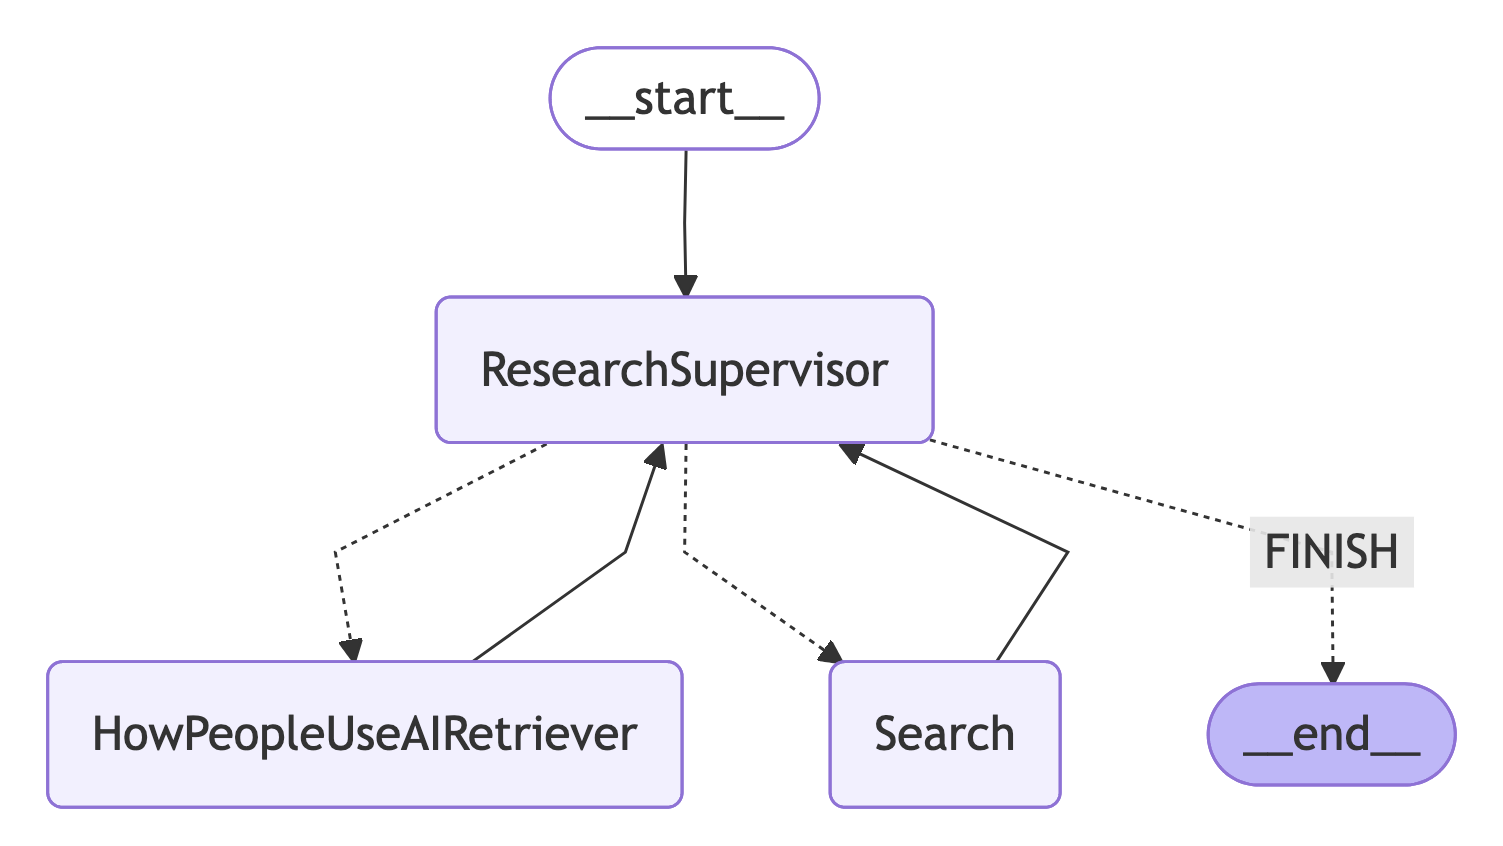

In [231]:
from IPython.display import Image, display
from langchain_core.runnables.graph import MermaidDrawMethod

display(Image(compiled_research_graph.get_graph().draw_mermaid_png(draw_method=MermaidDrawMethod.PYPPETEER)))

The next part is key - since we need to "wrap" our LangGraph in order for it to be compatible in the following steps - let's create an LCEL chain out of it!

This allows us to "broadcast" messages down to our Research Team LangGraph!

In [232]:
def enter_research_chain(message: str):
    results = {
        "messages": [HumanMessage(content=message)],
    }
    return results

research_chain = enter_research_chain | compiled_research_graph

Now, finally, we can take it for a spin!

In [233]:
for s in research_chain.stream(
    "How are people using AI to improve their lives?", {"recursion_limit": 100}
):
    if "__end__" not in s:
        print(s)
        print("---")

{'ResearchSupervisor': {'next': 'HowPeopleUseAIRetriever'}}
---
{'HowPeopleUseAIRetriever': {'messages': [HumanMessage(content="People are using AI, particularly ChatGPT, in various ways to improve their lives. Key applications include:\n\n1. **Education**: Users seek tutoring or teaching assistance, enhancing their learning experience.\n2. **Practical Guidance**: Many interactions involve requesting advice or instructions on a wide range of topics.\n3. **Writing and Content Modification**: Users frequently ask for help with writing tasks, including modifying existing text or generating new content.\n4. **Software and Technical Help**: ChatGPT is utilized for computer programming, mathematical calculations, and data analysis.\n5. **Personal Reflection and Relationships**: Some users engage with ChatGPT for personal insights or relationship advice.\n6. **Creating Digital Products**: Users leverage ChatGPT's capabilities to produce digital outputs, such as spreadsheets and code, improvin

##### 🏗️ Activity #2:

Using whatever drawing application you wish - please label the flow above on a diagram of your graph.

### Research Graph Flow Analysis

Here's the detailed flow of the `research_graph` showing the execution path and decision points:

![Research Graph Flow](diagrams/research_flow/research_graph_flow.png)

**Source Files:**
- **Mermaid Source**: [research_graph_flow.mmd](diagrams/research_flow/research_graph_flow.mmd)
- **Documentation**: [research_graph_flow.md](diagrams/research_flow/research_graph_flow.md)

**Key Flow Characteristics:**

1. **Entry Point**: `ResearchSupervisor` (set as entry point)
2. **Decision Making**: Supervisor decides which agent to call next based on the research task
3. **Agent Execution**: 
   - `Search` agent uses Tavily for web search
   - `HowPeopleUseAIRetriever` agent uses RAG for document retrieval
4. **Return Path**: Both agents return to supervisor after completion
5. **State Management**: All nodes share the `ResearchTeamState` with messages, team members, and next action
6. **Termination**: Supervisor can decide to `FINISH` when research is complete

**Execution Pattern:**
```
ResearchSupervisor → [Search|RAG] → ResearchSupervisor → [Search|RAG|FINISH]
```

##### ❓ Question #2:

How could you make sure your Agent uses specific tools that you wish it to use? Are there any ways to concretely set a flow through tools?

##### ✅ Answer:
- Generally, the tool descriptions should be clear. 
- Reducing the number of tools in LLM's toolbelt, to only include what is required.
- Describing input arguments and output payload clearly. Reducing the complexity of the input and output types.
- Hard constraints - Creating explicit graph edges to ensure the flow includes specific tool usage.
- Soft constraints - Explicit details in the prompt to use a specific tool for a specific task.

To set a flow through tools,
- Creating a specific node in the graph for tool call
- Conditional routing to branch into specific tool usage - e.g., if Arxiv tool doesnt retrive data, then search with Tavily tool
- Explicit instructions in the Prompt to follow a specific path after or before tool usage. 

# 🤝 BREAKOUT ROOM #2

## Task 4: Document Writing Team - A LangGraph for Planning, Writing, and Editing a Formal Research Resport.

Let's run it all back, this time specifically creating tools, agent nodes, and a graph for Planning, Writing, and Editing a Formal Research Resport!

#### Previous Cohort Use Case Data

Let's add a retriever for [previous cohort use-case data](./data/AIE7_Projects_with_Domains.csv) here!

This will allow our response writing team reference previous responses!

In [234]:
from langchain_community.document_loaders import CSVLoader

previous_cohort_loader = CSVLoader("data/AIE7_Projects_with_Domains.csv", content_columns=["Project Domain", "Secondary Domain (if any)"])
previous_cohort = previous_cohort_loader.load()
previous_cohort[0]

Document(metadata={'source': 'data/AIE7_Projects_with_Domains.csv', 'row': 0}, page_content='Project Domain: Customer Support / Helpdesk\nSecondary Domain (if any): Productivity Assistants')

In [235]:
qdrant_previous_cohort_vectorstore = Qdrant.from_documents(
    documents=previous_cohort,
    embedding=embedding_model,
    location=":memory:"
)

In [236]:
qdrant_previous_cohort_retriever = qdrant_previous_cohort_vectorstore.as_retriever()

### Tool Creation

Let's create some tools that will help us understand, open, work with, and edit documents to our liking!

In [237]:
from pathlib import Path
from tempfile import TemporaryDirectory
from typing import Dict, Optional
from typing_extensions import TypedDict
import uuid
import os

os.makedirs('./content/data', exist_ok=True)

def create_random_subdirectory():
    random_id = str(uuid.uuid4())[:8]  # Use first 8 characters of a UUID
    subdirectory_path = os.path.join('./content/data', random_id)
    os.makedirs(subdirectory_path, exist_ok=True)
    return subdirectory_path

WORKING_DIRECTORY = Path(create_random_subdirectory())

@tool
def create_outline(
    points: Annotated[List[str], "List of main points or sections."],
    file_name: Annotated[str, "File path to save the outline."],
) -> Annotated[str, "Path of the saved outline file."]:
    """Create and save an outline."""
    with (WORKING_DIRECTORY / file_name).open("w") as file:
        for i, point in enumerate(points):
            file.write(f"{i + 1}. {point}\n")
    return f"Outline saved to {file_name}"


@tool
def read_document(
    file_name: Annotated[str, "File path to save the document."],
    start: Annotated[Optional[int], "The start line. Default is 0"] = None,
    end: Annotated[Optional[int], "The end line. Default is None"] = None,
) -> str:
    """Read the specified document."""
    with (WORKING_DIRECTORY / file_name).open("r") as file:
        lines = file.readlines()
    if start is not None:
        start = 0
    return "\n".join(lines[start:end])

@tool
def write_document(
    content: Annotated[str, "Text content to be written into the document."],
    file_name: Annotated[str, "File path to save the document."],
) -> Annotated[str, "Path of the saved document file."]:
    """Create and save a text document."""
    with (WORKING_DIRECTORY / file_name).open("w") as file:
        file.write(content)
    return f"Document saved to {file_name}"

### Previous Cohort Use Case Data
@tool 
def reference_previous_responses(
    query: Annotated[str, "The query to search for in the previous responses."],
) -> Annotated[str, "The previous responses that match the query."]:
    """Search for previous responses that match the query."""
    return qdrant_previous_cohort_retriever.invoke(query)


@tool
def edit_document(
    file_name: Annotated[str, "Path of the document to be edited."],
    inserts: Annotated[
        Dict[int, str],
        "Dictionary where key is the line number (1-indexed) and value is the text to be inserted at that line.",
    ] = {},
) -> Annotated[str, "Path of the edited document file."]:
    """Edit a document by inserting text at specific line numbers."""

    with (WORKING_DIRECTORY / file_name).open("r") as file:
        lines = file.readlines()

    sorted_inserts = sorted(inserts.items())

    for line_number, text in sorted_inserts:
        if 1 <= line_number <= len(lines) + 1:
            lines.insert(line_number - 1, text + "\n")
        else:
            return f"Error: Line number {line_number} is out of range."

    with (WORKING_DIRECTORY / file_name).open("w") as file:
        file.writelines(lines)

    return f"Document edited and saved to {file_name}"

##### 🏗️ Activity #3:

Describe, briefly, what each of these tools is doing in your own words.

1. create_outline: Creates a numbered list of outline points and saves as text file
2. read_document: Reads a file and returns its contents. Supports optional starting and ending line range
3. write_document: Creates or overwrites a the file
4. reference_previous_responses: RAG over previous responses to retrieve any matches with the query
5. edit_document: Inserts new text at specific line numbers

### Document Writing State

Just like with our Research Team state - we want to keep track of a few things, however this time - we also want to keep track of which files we've created - so let's add that here!

In [238]:
import operator
from pathlib import Path

class DocWritingState(TypedDict):
    messages: Annotated[List[BaseMessage], operator.add]
    team_members: str
    next: str
    current_files: str

### Document Writing Prelude Function

Since we have a working directory - we want to be clear about what our current working directory looks like - this helper function will allow us to do that cleanly!

In [239]:
def prelude(state):
    written_files = []
    if not WORKING_DIRECTORY.exists():
        WORKING_DIRECTORY.mkdir()
    try:
        written_files = [
            f.relative_to(WORKING_DIRECTORY) for f in WORKING_DIRECTORY.rglob("*")
        ]
    except:
        pass
    if not written_files:
        return {**state, "current_files": "No files written."}
    return {
        **state,
        "current_files": "\nBelow are files your team has written to the directory:\n"
        + "\n".join([f" - {f}" for f in written_files]),
    }

### Document Writing Node Creation



In [240]:
authoring_llm = ChatOpenAI(model="gpt-4o-mini")

In [241]:
doc_writer_agent = create_agent(
    authoring_llm,
    [write_document, edit_document, read_document],
    ("You are an expert writing customer assistance responses.\n"
    "Below are files currently in your directory:\n{current_files}"),
)
context_aware_doc_writer_agent = prelude | doc_writer_agent
doc_writing_node = functools.partial(
    agent_node, agent=context_aware_doc_writer_agent, name="DocWriter"
)

note_taking_agent = create_agent(
    authoring_llm,
    [create_outline, read_document, reference_previous_responses],
    ("You are an expert senior researcher tasked with writing a customer assistance outline and"
    " taking notes to craft a customer assistance response.\n{current_files}"),
)
context_aware_note_taking_agent = prelude | note_taking_agent
note_taking_node = functools.partial(
    agent_node, agent=context_aware_note_taking_agent, name="NoteTaker"
)

copy_editor_agent = create_agent(
    authoring_llm,
    [write_document, edit_document, read_document],
    ("You are an expert copy editor who focuses on fixing grammar, spelling, and tone issues\n"
    "Below are files currently in your directory:\n{current_files}"),
)
context_aware_copy_editor_agent = prelude | copy_editor_agent
copy_editing_node = functools.partial(
    agent_node, agent=context_aware_copy_editor_agent, name="CopyEditor"
)

authoring_supervisor_agent = create_team_supervisor(
    authoring_llm,
    ("You are a supervisor tasked with managing a conversation between the"
    " following workers: {team_members}. You should always verify the technical"
    " contents after any edits are made. "
    "Given the following user request,"
    " respond with the worker to act next. Each worker will perform a"
    " task and respond with their results and status. When each team is finished,"
    " you must respond with FINISH."),
    ["DocWriter", "NoteTaker", "CopyEditor"],
)

### Document Writing Team LangGraph Construction

This part is almost exactly the same (with a few extra nodes) as our Research Team LangGraph construction - so we'll leave it as one block!

In [242]:
authoring_graph = StateGraph(DocWritingState)
authoring_graph.add_node("DocWriter", doc_writing_node)
authoring_graph.add_node("NoteTaker", note_taking_node)
authoring_graph.add_node("CopyEditor", copy_editing_node)
authoring_graph.add_node("AuthoringSupervisor", authoring_supervisor_agent)

authoring_graph.add_edge("DocWriter", "AuthoringSupervisor")
authoring_graph.add_edge("NoteTaker", "AuthoringSupervisor")
authoring_graph.add_edge("CopyEditor", "AuthoringSupervisor")

authoring_graph.add_conditional_edges(
    "AuthoringSupervisor",
    lambda x: x["next"],
    {
        "DocWriter": "DocWriter",
        "NoteTaker": "NoteTaker",
        "CopyEditor" : "CopyEditor",
        "FINISH": END,
    },
)

authoring_graph.set_entry_point("AuthoringSupervisor")

In [243]:
compiled_authoring_graph = authoring_graph.compile()

#### Display Graph

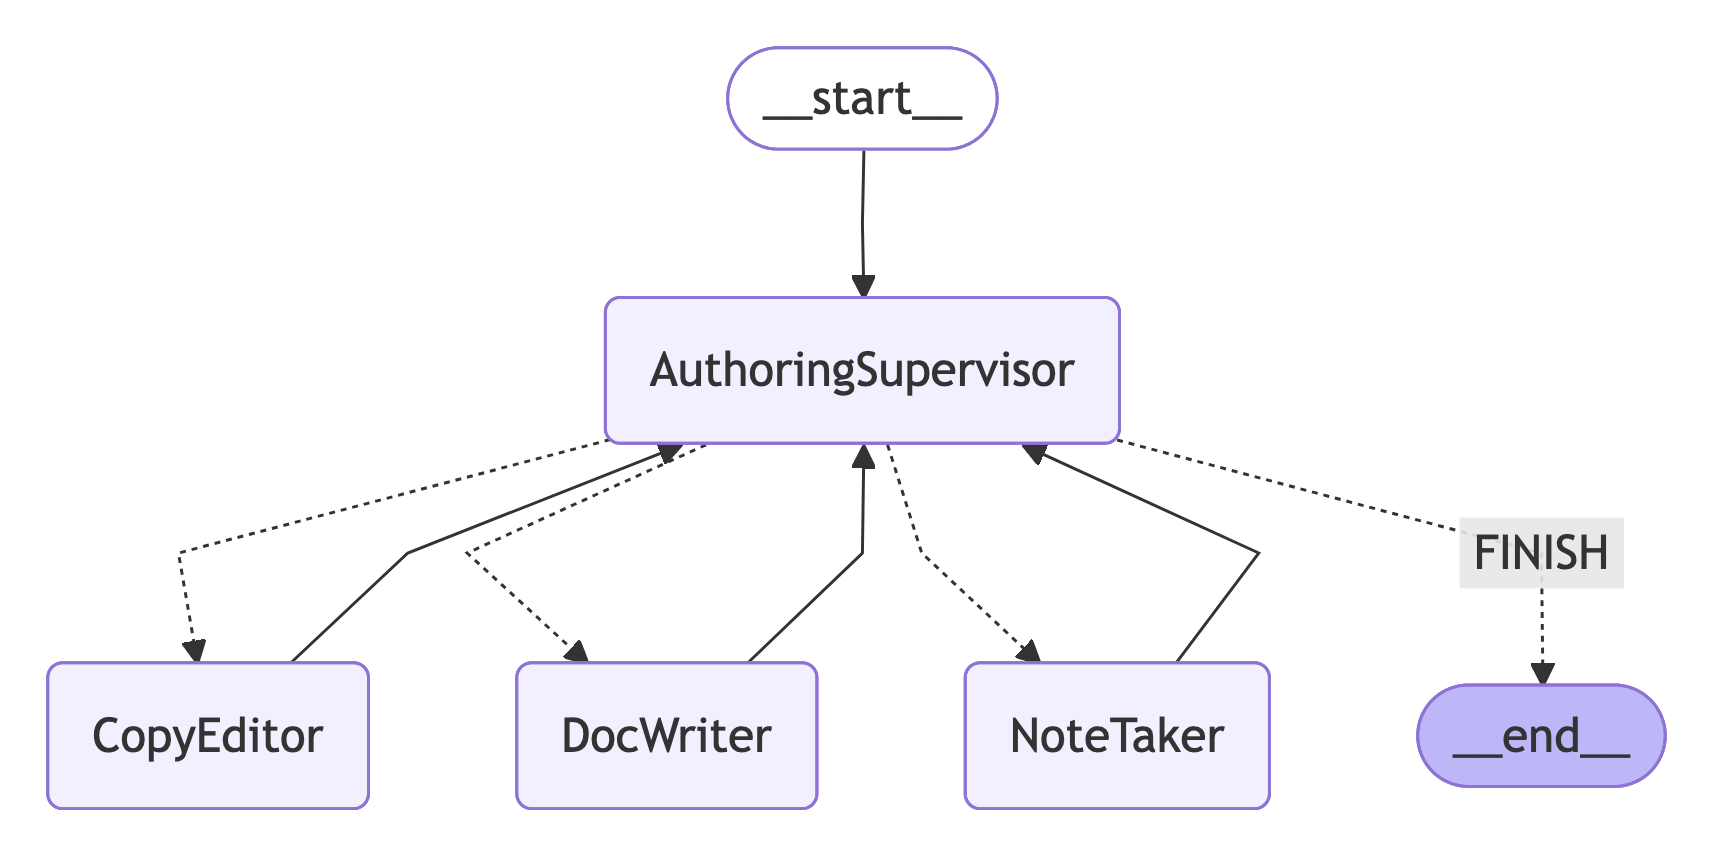

In [244]:

display(Image(compiled_authoring_graph.get_graph().draw_mermaid_png(draw_method=MermaidDrawMethod.PYPPETEER)))

Just as before - we'll need to create an "interface" between the level above, and our graph.

In [245]:
def enter_authoring_chain(message: str, members: List[str]):
    results = {
        "messages": [HumanMessage(content=message)],
        "team_members": ", ".join(members),
    }
    return results

authoring_chain = (
    functools.partial(enter_authoring_chain, members=authoring_graph.nodes)
    | compiled_authoring_graph
)

Now we can test this out!

> NOTE: It is possible you may see an error here - rerun the cell to clear.

In [246]:
for s in authoring_chain.stream(
    "What are the most common use-cases in this data. What are the most common domains?",
    {"recursion_limit": 100},
):
    if "__end__" not in s:
        print(s)
        print("---")

{'AuthoringSupervisor': {'next': 'DocWriter'}}
---
{'DocWriter': {'messages': [HumanMessage(content='As an expert in customer assistance, I can provide insights into common use cases and domains typically observed in customer interactions. Here are some prevalent use cases and domains:\n\n### Common Use-Cases:\n1. **Product Inquiry**: Customers often seek information about product features, specifications, availability, and pricing.\n   \n2. **Order Tracking**: Customers frequently inquire about the status of their orders, including shipping updates and delivery times.\n\n3. **Returns and Refunds**: Many interactions involve questions about return policies, processes for returning items, and timelines for refunds.\n\n4. **Technical Support**: Customers may need assistance with troubleshooting products, accessing services, or resolving technical issues.\n\n5. **Account Management**: Users often seek help with account-related tasks such as password resets, login issues, and account updat

### Authoring Graph Flow Analysis

Here's the detailed flow of the `authoring_graph` showing the execution path and decision points:

![Authoring Graph Flow](diagrams/authoring_flow/authoring_graph_flow.png)

**Source Files:**
- **Mermaid Source**: [authoring_graph_flow.mmd](diagrams/authoring_flow/authoring_graph_flow.mmd)
- **Documentation**: [authoring_graph_flow.md](diagrams/authoring_flow/authoring_graph_flow.md)

**Key Flow Characteristics:**

1. **Entry Point**: `AuthoringSupervisor` (set as entry point)
2. **Decision Making**: Supervisor decides which agent to call next based on the writing task
3. **Agent Execution**: 
   - `DocWriter` creates and writes content
   - `NoteTaker` creates outlines and researches
   - `CopyEditor` refines grammar and style
4. **Return Path**: All agents return to supervisor after completion
5. **State Management**: All nodes share the `DocWritingState` with messages, team members, current files, and next action
6. **Termination**: Supervisor can decide to `FINISH` when writing is complete

**Execution Pattern:**
```
AuthoringSupervisor → [DocWriter|NoteTaker|CopyEditor] → AuthoringSupervisor → [DocWriter|NoteTaker|CopyEditor|FINISH]
```


## Task 5: Meta-Supervisor and Full Graph

Finally, now that we have our two LangGraph agents (some of which are already multi-agent), we can build a supervisor that sits above all of them!

The final process, surprisingly, is quite straight forward!

Let's jump in!

First off - we'll need to create our supervisor agent node.

In [247]:
from langchain_core.messages import AIMessage, BaseMessage, HumanMessage
from langchain_openai.chat_models import ChatOpenAI

super_llm = ChatOpenAI(model="gpt-4o-mini")

super_supervisor_agent = create_team_supervisor(
    super_llm,
    "You are a supervisor tasked with managing a conversation between the"
    " following teams: {team_members}. Given the following user request,"
    " respond with the worker to act next. Each worker will perform a"
    " task and respond with their results and status. When all workers are finished,"
    " you must respond with FINISH.",
    ["Research team", "Response team"],
)

We'll also create our new state - as well as some methods to help us navigate the new state and the subgraphs.

> NOTE: We only pass the most recent message from the parent graph to the subgraph, and we only extract the most recent message from the subgraph to include in the state of the parent graph.

In [248]:
class State(TypedDict):
    messages: Annotated[List[BaseMessage], operator.add]
    next: str

def get_last_message(state: State) -> str:
    return state["messages"][-1].content

def join_graph(response: dict):
    return {"messages": [response["messages"][-1]]}

Next, we'll create our base graph.

Notice how each node we're adding is *AN ENTIRE LANGGRAPH AGENT* (wrapped into an LCEL chain with our helper functions above).

In [249]:
super_graph = StateGraph(State)

super_graph.add_node("Research team", get_last_message | research_chain | join_graph)
super_graph.add_node("Response team", get_last_message | authoring_chain | join_graph)
super_graph.add_node("SuperSupervisor", super_supervisor_agent)

Next, we'll create our edges!

This process is completely idenctical to what we've seen before - just addressing the LangGraph subgraph nodes instead of individual nodes.

In [250]:
super_graph.add_edge("Research team", "SuperSupervisor")
super_graph.add_edge("Response team", "SuperSupervisor")
super_graph.add_conditional_edges(
    "SuperSupervisor",
    lambda x: x["next"],
    {
        "Response team": "Response team",
        "Research team": "Research team",
        "FINISH": END,
    },
)
super_graph.set_entry_point("SuperSupervisor")

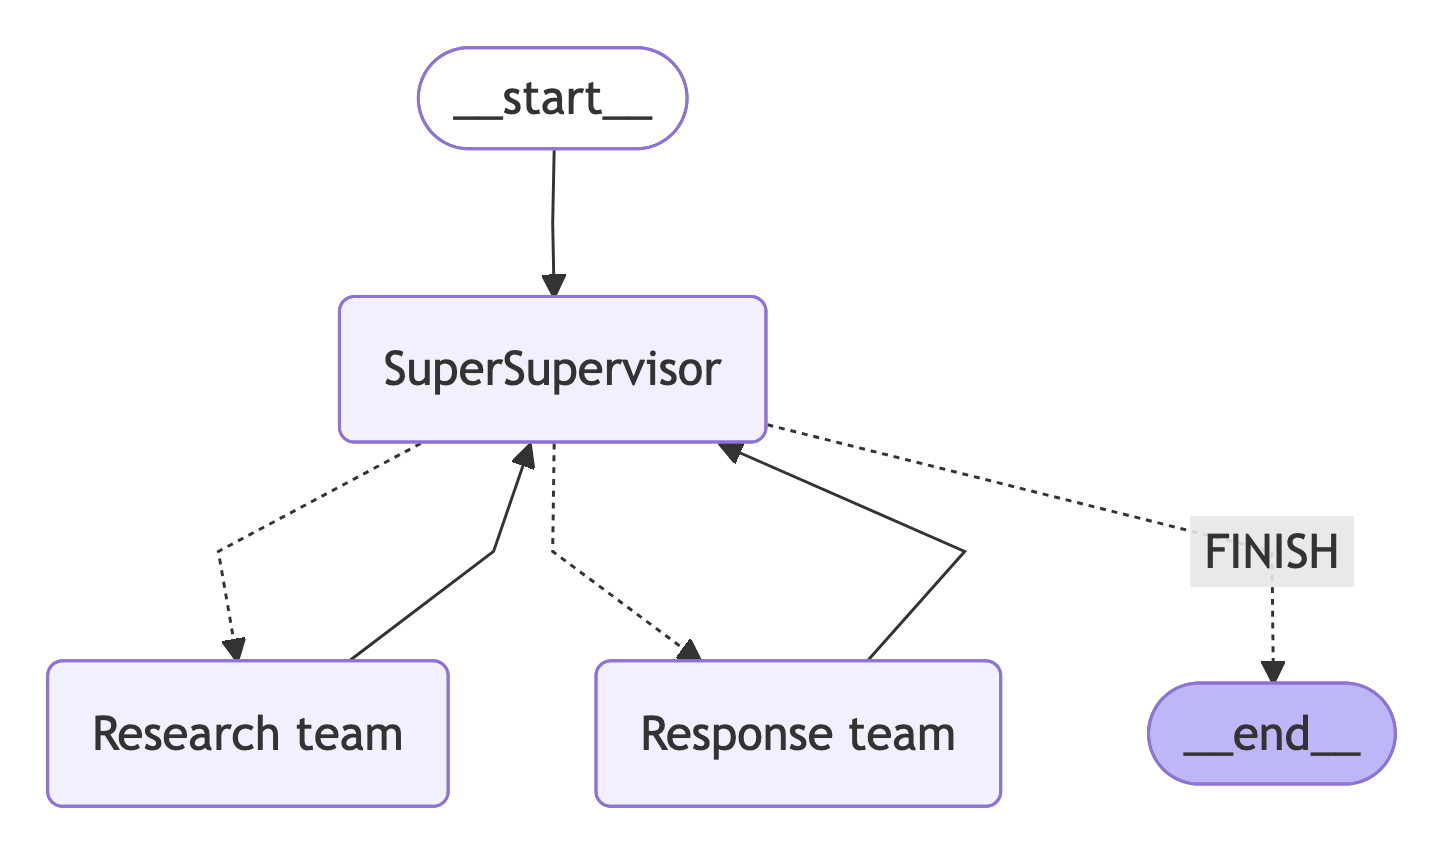

In [251]:
compiled_super_graph = super_graph.compile()

display(Image(compiled_super_graph.get_graph().draw_mermaid_png(draw_method=MermaidDrawMethod.PYPPETEER)))

That's it!

Now we can finally use our full agent!

In [ ]:
WORKING_DIRECTORY = Path(create_random_subdirectory())

for s in compiled_super_graph.stream(
    {
        "messages": [
            HumanMessage(
                #Write a report on the rise of context engineering in the LLM Space in 2025, and how it's impacting how people are using AI.
                content="Write a report on Evaluations in LLM applications."
            )
        ],
    },
    {"recursion_limit": 30},
):
    if "__end__" not in s:
        print(s)
        print("---")

{'SuperSupervisor': {'next': 'Research team'}}
---
{'Research team': {'messages': [HumanMessage(content="# Report on Evaluations in LLM Applications\n\n## Introduction\nEvaluating Large Language Models (LLMs) is essential for ensuring that these intricate AI systems are effective across a broad spectrum of tasks. With LLMs gaining traction in various domains, developing standardized, rigorous evaluation methodologies is crucial. This report summarizes contemporary evaluation metrics, methodologies, challenges, and best practices in LLM applications based on recent findings.\n\n## Key Evaluation Metrics\n1. **Correctness and Accuracy**: This metric quantifies whether the LLM's outputs are correct responses to the input prompts. Ensuring high accuracy is critical for applications requiring precise answers, especially in technical or factual contexts.\n\n2. **Semantic Similarity**: This measures how closely the responses generated by the LLM align with the intended meaning of the prompts,

________________________________________________________________

# Report on Evaluations in LLM Applications

## Introduction
Evaluating Large Language Models (LLMs) is essential for ensuring that these intricate AI systems are effective across a broad spectrum of tasks. With LLMs gaining traction in various domains, developing standardized, rigorous evaluation methodologies is crucial. This report summarizes contemporary evaluation metrics, methodologies, challenges, and best practices in LLM applications based on recent findings.

## Key Evaluation Metrics
1. **Correctness and Accuracy**: This metric quantifies whether the LLM's outputs are correct responses to the input prompts. Ensuring high accuracy is critical for applications requiring precise answers, especially in technical or factual contexts.

2. **Semantic Similarity**: This measures how closely the responses generated by the LLM align with the intended meaning of the prompts, focusing on semantic understanding rather than mere textual similarity.

3. **Hallucination Rate**: This metric examines the prevalence of inaccurate or misleading information produced by the LLM, which is crucial in applications where factual correctness is paramount.

4. **Quality of Responses**: A multifaceted evaluation can include coherence, relevance, sentiment analysis, and toxicity detection, providing insights into the suitability of LLM outputs in specific contexts.

5. **Task-Specific Metrics**: Different applications may necessitate unique metrics tailored to their objectives. For instance, chatbots might be evaluated on user engagement, while summarization tools could be assessed for conciseness and completeness.

## Evaluation Approaches
1. **LLM-as-a-Judge Framework**: This approach uses the LLM itself to assess its outputs. By leveraging the model's capacity to understand language patterns, this framework can provide insights into its performance against established criteria.

2. **Human-in-the-Loop Evaluation**: Involving human evaluators allows for nuanced assessments of model performance. While informative, this method can be labor-intensive and subject to variability in judgments.

3. **Automated Testing Frameworks**: Automated frameworks for prompt evaluation facilitate ongoing assessment at scale, providing a consistent benchmark against which model outputs can be measured continuously.

## Challenges in Evaluation
1. **Context Sensitivity**: Success metrics developed for one domain may not be valid in another, necessitating context-aware evaluation strategies.

2. **Human Evaluation Subjectivity**: Evaluators' subjective judgments can introduce variability in performance assessments, calling for strategies to mitigate discrepancies.

3. **Cost and Scalability**: The intensive nature of human evaluations can restrict scalability. Balancing thorough evaluation with cost-effectiveness while striving for automation poses a technical challenge.

## Recent Developments
Recent literature indicates a growing interest in LLM evaluations, with a notable increase in research exploring methodologies, metrics, and application contexts. Emerging studies reflect advancements in evaluating multi-agent systems, application-specific success metrics, and the integration of LLM evaluations into continuous improvement processes, emphasizing a demand for scalable and effective testing strategies.

## Best Practices
1. **Objective Clarity**: Clearly articulating LLM objectives aids in determining appropriate evaluation metrics.

2. **Iterative Testing**: Continuous evaluation coupled with feedback mechanisms refines model performance and validation processes.

3. **Comprehensive Evaluation Frameworks**: Developing a thorough evaluation framework encompassing various performance aspects ensures a well-rounded appraisal of the LLM's capabilities.

4. **Domain-Specific Tailoring**: Metrics and strategies should be customized based on application-specific requirements to enhance the relevance and effectiveness of evaluations.

## Conclusion
The effective evaluation of LLM applications is integral to the successful deployment and trustworthiness of these technologies. By embracing a blend of well-defined metrics, innovative evaluation methodologies, and contextual awareness, stakeholders can optimize LLM performance to meet user expectations across various domains.

For further reading, the following sources provide additional insights on LLM evaluation metrics and practices:
- [How People Use ChatGPT - SSRN](https://ssrn.com/abstract=5232910)
- [LLM-based Application Evaluation - Deepchecks](https://www.deepchecks.com/llm-based-application-evaluation/)
- [Evaluation and Benchmarking of LLM Agents: A Survey - arXiv](https://arxiv.org/html/2507.21504v1)






________________________________________________________________






# Multi-Agent System Architecture

Here's a comprehensive diagram showing the hierarchical multi-agent workflow:

![Multi-Agent Architecture](diagrams/architecture/multi_agent_architecture.png)

**Source Files:**
- **Mermaid Source**: [multi_agent_architecture.mmd](diagrams/architecture/multi_agent_architecture.mmd)
- **Documentation**: [multi_agent_architecture.md](diagrams/architecture/multi_agent_architecture.md)
